In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cp"

In [ ]:
tfm = transforms.Compose([
  transforms.RandomRotation(15),
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),

])


In [ ]:
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=tfm
)
test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=tfm
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=True
)

In [ ]:
class CNN(nn.Module):

  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Dropout(0.5),
        nn.Linear(64*5*5, 10)
    )
    # 28 x 28 -> 26 x 26 -> 13 x 13
    # 13 x 13 -> 11 x 11 -> 5 x 5

  def forward(self, x):
    return self.net(x)

In [ ]:
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), weight_decay=0.0001)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(5):
  model.train()
  for xb, yb in train_loader:
    xb, yb = xb.to(device), yb.to(device)
    optimizer.zero_grad()
    loss = loss_fn(model(xb), yb)
    loss.backward()
    optimizer.step()

In [ ]:
def evaluate(loader):
  model.eval() #dropout off
  y_pred, y_true = [], [] #add
  with torch.no_grad():
    for xb, yb in loader:
      xb, yb = xb.to(device), yb.to(device)
      y_pred += model(xb).argmax(dim=1).tolist()
      y_true += yb.tolist()
  acc = 100 * sum([y_pred[i] == y_true[i] for i in range(len(y_pred))]) / len(y_pred)
  return acc, y_pred, y_true
#

In [ ]:
print(evaluate(train_loader)[0])
print(evaluate(test_loader)[0])

86.825
85.77


In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
names = test_ds.classes
test_acc, y_pred, y_true = evaluate(test_loader)
print(classification_report(y_true, y_pred, target_names=names))

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.84      0.82      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.82      0.81      0.82      1000
       Dress       0.85      0.89      0.87      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.95      0.95      0.95      1000
       Shirt       0.65      0.56      0.60      1000
     Sneaker       0.94      0.88      0.91      1000
         Bag       0.94      0.97      0.95      1000
  Ankle boot       0.91      0.96      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



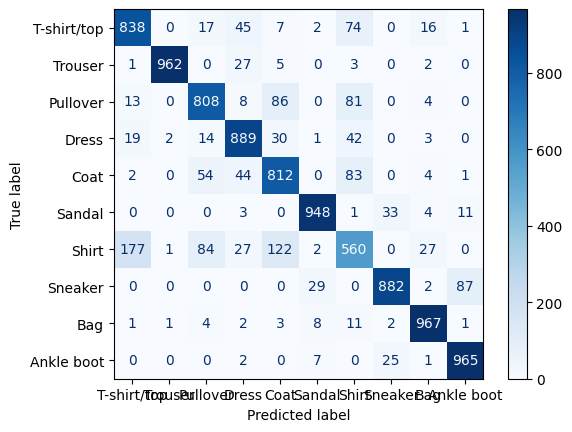

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
  labels = range(10),
  display_labels = names,
  cmap = "Blues")

In [ ]:
torch.save(model.state_dict(), "fashion_model.pt")

In [ ]:
model = CNN()
model.load_state_dict(
    torch.load("fashion_model.pt", weights_only = True)
)

<All keys matched successfully>